# Modelagem e Simulação de Cadeias de Markov: Fundamentos e Aplicação Financeira (PETR4)

Este notebook explora a teoria e a prática das **Cadeias de Markov**, começando por conceitos fundamentais e simulações estocásticas, até chegar a uma aplicação real utilizando dados do mercado financeiro brasileiro.

## 1. Fundamentos das Cadeias de Markov e Distribuição Estacionária

Uma Cadeia de Markov é um modelo estocástico que descreve uma sequência de eventos possíveis onde a probabilidade de cada evento depende apenas do estado alcançado no evento anterior. Essa é a chamada **Propriedade de Markov** (ou propriedade de ausência de memória).

Matematicamente, se $X_t$ é o estado do sistema no tempo $t$, temos:
$$P(X_{t+1} = j \mid X_t = i, X_{t-1} = k, \dots) = P(X_{t+1} = j \mid X_t = i) = p_{ij}$$

As probabilidades de transição entre os estados são organizadas em uma **Matriz de Transição** $P$. Se o vetor de estado inicial é $\pi_0$, o estado do sistema após $n$ passos é dado por:
$$\pi_n = \pi_0 P^n$$

Ao iterar esse processo para $n \to \infty$, uma cadeia ergódica converge para um equilíbrio de longo prazo chamado **Distribuição Estacionária** ($\pi$), onde as probabilidades param de mudar:
$$\pi = \pi P$$

> **OBS.:** Uma **cadeia ergódica**, no contexto das Cadeias de Markov, é um sistema estocástico que possui a propriedade fundamental de "esquecer" seu estado inicial a longo prazo, garantindo a convergência para uma única distribuição de probabilidade estável, conhecida como distribuição estacionária. Para que uma cadeia receba essa classificação, ela precisa obrigatoriamente satisfazer duas condições matemáticas: ser **irredutível**, o que significa que é possível transitar de qualquer estado para qualquer outro estado em um número finito de passos (sem "ilhas" isoladas ou estados absorventes dos quais não se pode sair), e ser **aperiódica**, indicando que o sistema não retorna a um estado em ciclos de repetição temporal rígidos.  Na prática computacional e financeira, isso garante que, se simularmos o processo por tempo suficiente, a proporção temporal que o sistema gasta em cada estado refletirá exatamente suas probabilidades de equilíbrio, independentemente da condição em que a simulação começou.

In [1]:
#! pip install yfinance

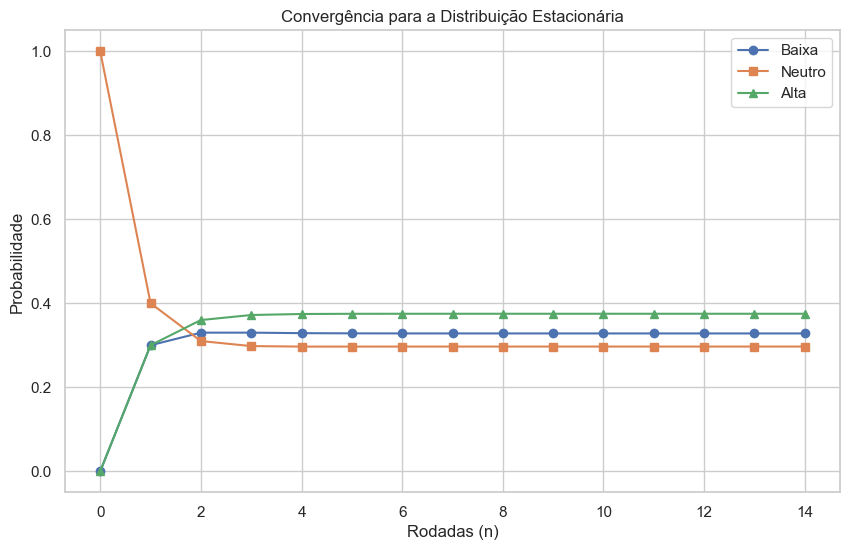

Distribuição Estacionária Final: [0.328125 0.296875 0.375   ]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# Configuração de estilo para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ==========================================
# 1. CADEIA DE MARKOV SIMPLES E CONVERGÊNCIA
# ==========================================

# Definindo os estados: 0 = Baixa, 1 = Neutro, 2 = Alta
estados = ['Baixa', 'Neutro', 'Alta']

# Matriz de Transição Teórica (3x3)
# As linhas devem somar 1.
P_teorica = np.array([
    [0.5, 0.2, 0.3], # De Baixa para: Baixa, Neutro, Alta
    [0.3, 0.4, 0.3], # De Neutro para: Baixa, Neutro, Alta
    [0.2, 0.3, 0.5]  # De Alta para: Baixa, Neutro, Alta
])

# Estado inicial: 100% de certeza que começa em 'Neutro'
pi_0 = np.array([0.0, 1.0, 0.0])

# Simulando a evolução das probabilidades por 15 rodadas
n_steps = 15
evolucao_probs = np.zeros((n_steps, 3))
pi_atual = pi_0

for i in range(n_steps):
    evolucao_probs[i] = pi_atual
    pi_atual = np.dot(pi_atual, P_teorica)

# Visualizando a convergência para a distribuição estacionária
plt.plot(evolucao_probs[:, 0], label='Baixa', marker='o')
plt.plot(evolucao_probs[:, 1], label='Neutro', marker='s')
plt.plot(evolucao_probs[:, 2], label='Alta', marker='^')
plt.title("Convergência para a Distribuição Estacionária")
plt.xlabel("Rodadas (n)")
plt.ylabel("Probabilidade")
plt.legend()
plt.show()

print("Distribuição Estacionária Final:", pi_atual)

## 2. Simulação Empírica (Monte Carlo) e Estatísticas

Embora a multiplicação de matrizes nos dê as probabilidades exatas, sistemas reais transitam de um estado discreto para outro. Podemos simular essa trajetória utilizando geração de números aleatórios baseada nas probabilidades da matriz de transição (Método de Monte Carlo).

Abaixo, criamos uma função para simular $N$ rodadas e extraímos três estatísticas visuais importantes:
1. **Histograma dos Estados:** Frequência absoluta de visitas a cada estado.
2. **Matriz de Transição Empírica (Heatmap):** A matriz reconstruída a partir das contagens reais da simulação (para comparar com a matriz teórica).
3. **Evolução dos Estados:** A proporção acumulada de cada estado ao longo do tempo.

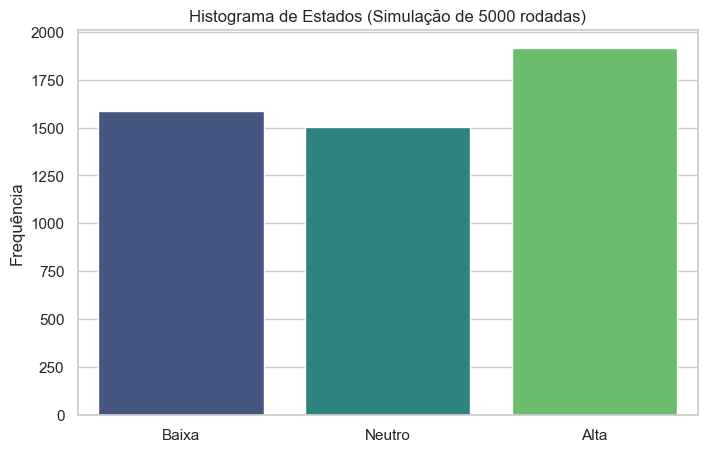

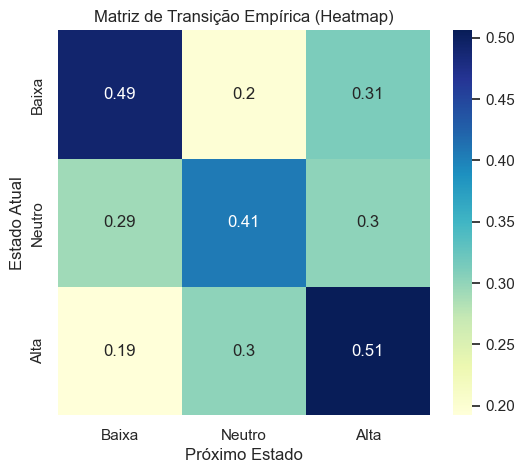

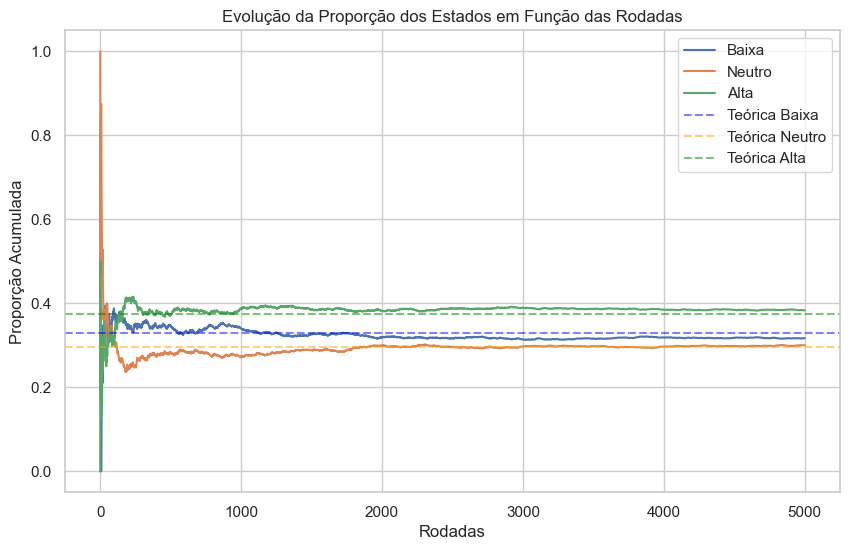

In [3]:
# ==========================================
# 2. SIMULAÇÃO EMPÍRICA DE PASSOS
# ==========================================

def simular_markov(matriz_transicao, estado_inicial, n_rodadas):
    n_estados = matriz_transicao.shape[0]
    caminho = [estado_inicial]
    estado_atual = estado_inicial
    
    for _ in range(n_rodadas):
        # Sorteia o próximo estado com base nas probabilidades da linha atual
        proximo_estado = np.random.choice(n_estados, p=matriz_transicao[estado_atual])
        caminho.append(proximo_estado)
        estado_atual = proximo_estado
        
    return np.array(caminho)

# Simulando 5000 rodadas
caminho_simulado = simular_markov(P_teorica, estado_inicial=1, n_rodadas=5000)

# --- Gráfico 1: Histograma de Estados ---
plt.figure(figsize=(8, 5))
sns.countplot(x=[estados[i] for i in caminho_simulado], order=estados, palette="viridis")
plt.title("Histograma de Estados (Simulação de 5000 rodadas)")
plt.ylabel("Frequência")
plt.show()

# --- Gráfico 2: Heatmap da Matriz de Transição Empírica ---
matriz_empirica = np.zeros_like(P_teorica)
for i in range(len(caminho_simulado)-1):
    estado_origem = caminho_simulado[i]
    estado_destino = caminho_simulado[i+1]
    matriz_empirica[estado_origem, estado_destino] += 1

# Normalizando as linhas para obter probabilidades
matriz_empirica = matriz_empirica / matriz_empirica.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(matriz_empirica, annot=True, cmap="YlGnBu", xticklabels=estados, yticklabels=estados)
plt.title("Matriz de Transição Empírica (Heatmap)")
plt.ylabel("Estado Atual")
plt.xlabel("Próximo Estado")
plt.show()

# --- Gráfico 3: Evolução das Proporções (Convergência Empírica) ---
# Calcula a proporção acumulada de cada estado ao longo das rodadas
ev_baixa = np.cumsum(caminho_simulado == 0) / np.arange(1, len(caminho_simulado) + 1)
ev_neutro = np.cumsum(caminho_simulado == 1) / np.arange(1, len(caminho_simulado) + 1)
ev_alta = np.cumsum(caminho_simulado == 2) / np.arange(1, len(caminho_simulado) + 1)

plt.figure(figsize=(10, 6))
plt.plot(ev_baixa, label='Baixa')
plt.plot(ev_neutro, label='Neutro')
plt.plot(ev_alta, label='Alta')
plt.axhline(y=pi_atual[0], color='blue', linestyle='--', alpha=0.5, label='Teórica Baixa')
plt.axhline(y=pi_atual[1], color='orange', linestyle='--', alpha=0.5, label='Teórica Neutro')
plt.axhline(y=pi_atual[2], color='green', linestyle='--', alpha=0.5, label='Teórica Alta')
plt.title("Evolução da Proporção dos Estados em Função das Rodadas")
plt.xlabel("Rodadas")
plt.ylabel("Proporção Acumulada")
plt.legend()
plt.show()

## 3. Aplicação Real: Modelagem de PETR4 com `yfinance`

Nesta seção, aplicaremos o conceito de Cadeias de Markov aos dados reais de fechamento das ações da Petrobras (**PETR4.SA**).

**Metodologia:**
1. **Coleta:** Extração dos últimos 5 anos de dados diários.
2. **Definição dos Estados:** Calcularemos o retorno diário $R_t = \frac{Fechamento_t - Fechamento_{t-1}}{Fechamento_{t-1}}$.
   - **Neutro:** Variação muito pequena, entre $-0.5\%$ e $+0.5\%$.
   - **Alta:** Variação $> +0.5\%$.
   - **Baixa:** Variação $< -0.5\%$.
3. **Divisão de Dados:**
   - **Treinamento:** Primeiros 4 anos (utilizados para calcular a Matriz de Transição real do ativo).
   - **Teste:** Último 1 ano (utilizado para comparar a distribuição real de estados contra uma simulação gerada pela nossa matriz).

Baixando dados para PETR4.SA...


[*********************100%***********************]  1 of 1 completed


Dias de Treinamento: 996
Dias de Teste: 249


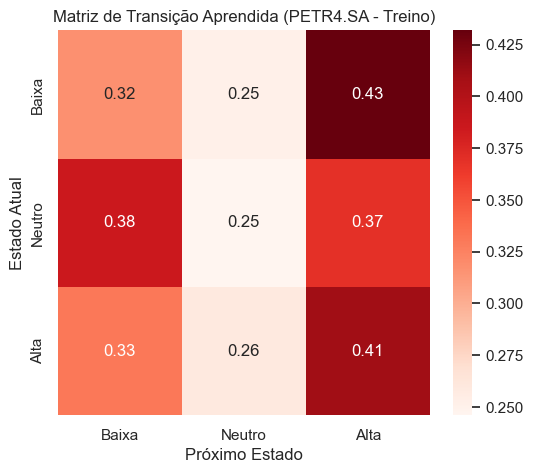

In [4]:
# ==========================================
# 3. EXTRAÇÃO DE DADOS E CONSTRUÇÃO DO MODELO
# ==========================================

# Parâmetros
ticker = 'PETR4.SA'
end_date = datetime.today()
start_date = end_date - timedelta(days=5*365) # Últimos 5 anos
split_date = end_date - timedelta(days=1*365) # Divisão no último 1 ano

# Baixando os dados
print(f"Baixando dados para {ticker}...")
df = yf.download(ticker, start=start_date, end=end_date)
df = df[['Close']].copy()
df.columns = ['Close'] # Simplificando MultiIndex

# Calculando retornos diários
df['Retorno'] = df['Close'].pct_change()
df = df.dropna()

# Definindo os estados (Limiar de 0.5%)
limiar = 0.005

def classificar_estado(retorno):
    if retorno < -limiar: return 0  # Baixa
    elif retorno > limiar: return 2 # Alta
    else: return 1                  # Neutro

df['Estado'] = df['Retorno'].apply(classificar_estado)

# Separando Treino e Teste
df_train = df[df.index <= split_date]
df_test = df[df.index > split_date]

print(f"Dias de Treinamento: {len(df_train)}")
print(f"Dias de Teste: {len(df_test)}")

# Construindo a Matriz de Transição baseada no Treinamento
matriz_petr4 = np.zeros((3, 3))
estados_train = df_train['Estado'].values

for i in range(len(estados_train)-1):
    origem = estados_train[i]
    destino = estados_train[i+1]
    matriz_petr4[origem, destino] += 1

# Transformando contagens em probabilidades
matriz_petr4 = matriz_petr4 / matriz_petr4.sum(axis=1, keepdims=True)

# Visualizando a Matriz de Transição Aprendida
plt.figure(figsize=(6, 5))
sns.heatmap(matriz_petr4, annot=True, cmap="Reds", xticklabels=estados, yticklabels=estados)
plt.title(f"Matriz de Transição Aprendida ({ticker} - Treino)")
plt.ylabel("Estado Atual")
plt.xlabel("Próximo Estado")
plt.show()

## 3.1 Análise Exploratória dos Dados (EDA)

Antes de construirmos e avaliarmos a nossa matriz de transição, é fundamental entender o comportamento histórico do ativo. Nesta Análise Exploratória, vamos observar três pontos principais:

1. **Evolução do Preço:** Como o preço de fechamento (Close) da PETR4 se comportou ao longo destes 5 anos.
2. **Distribuição dos Retornos:** Um histograma das variações percentuais diárias. Isso nos ajuda a visualizar a volatilidade do ativo e justifica visualmente os limites que escolhemos para definir o estado "Neutro" ($-0.5\%$ a $+0.5\%$).
3. **Estatísticas Descritivas:** Um resumo estatístico básico dos valores de fechamento e retorno.

ESTATÍSTICAS DESCRITIVAS - PETR4.SA


,Close,Retorno
count,1245.0000,1245.0000
mean,21.3784,0.0017
std,9.3630,0.0200
min,6.0594,-0.0920
25%,12.4053,-0.0082
50%,22.8465,0.0014
75%,30.1704,0.0126
max,41.1300,0.0799


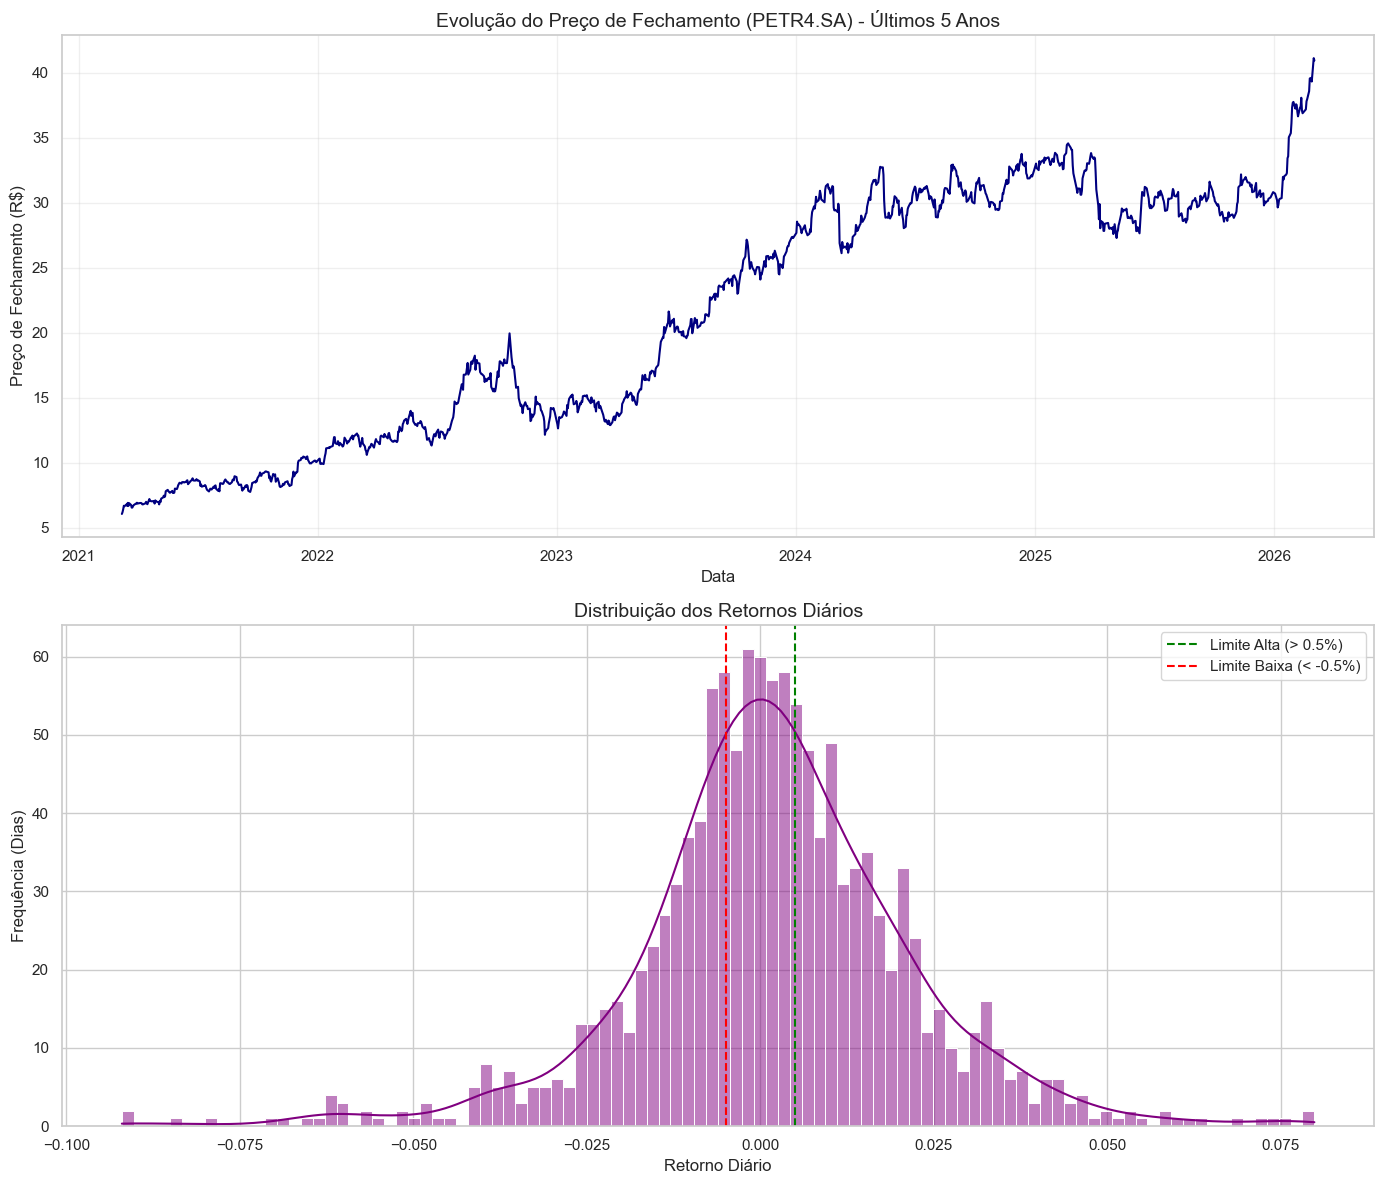

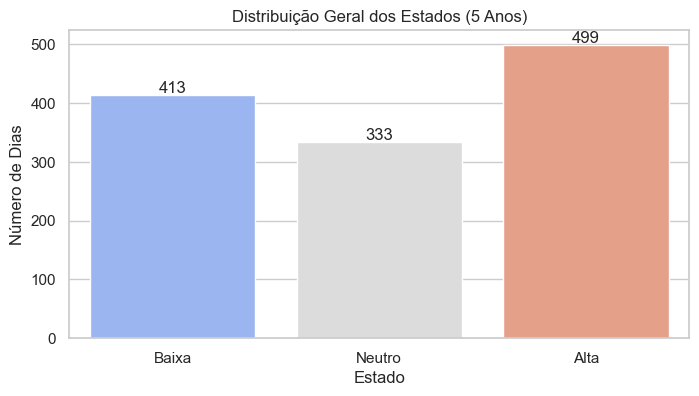

In [5]:
# ==========================================
# 3.1 ANÁLISE EXPLORATÓRIA DOS DADOS (EDA)
# ==========================================

# 1. Estatísticas Descritivas Básicas
print("="*50)
print(f"ESTATÍSTICAS DESCRITIVAS - {ticker}")
print("="*50)
display(df[['Close', 'Retorno']].describe().round(4))

# Configurando a área de plotagem para múltiplos gráficos
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# 2. Gráfico da Evolução do Preço de Fechamento
axes[0].plot(df.index, df['Close'], color='navy', linewidth=1.5)
axes[0].set_title(f"Evolução do Preço de Fechamento ({ticker}) - Últimos 5 Anos", fontsize=14)
axes[0].set_ylabel("Preço de Fechamento (R$)")
axes[0].set_xlabel("Data")
axes[0].grid(True, alpha=0.3)

# 3. Histograma da Distribuição dos Retornos Diários
sns.histplot(df['Retorno'], bins=100, kde=True, ax=axes[1], color='purple')
axes[1].set_title("Distribuição dos Retornos Diários", fontsize=14)
axes[1].set_xlabel("Retorno Diário")
axes[1].set_ylabel("Frequência (Dias)")

# Adicionando linhas verticais para mostrar nossos limites do estado "Neutro"
axes[1].axvline(x=limiar, color='green', linestyle='--', label=f'Limite Alta (> {limiar*100}%)')
axes[1].axvline(x=-limiar, color='red', linestyle='--', label=f'Limite Baixa (< {-limiar*100}%)')
axes[1].legend()

plt.tight_layout()
plt.show()

# 4. Proporção Geral dos Estados em todo o dataset (Treino + Teste)
plt.figure(figsize=(8, 4))
ax = sns.countplot(x=df['Estado'].map({0: 'Baixa', 1: 'Neutro', 2: 'Alta'}), 
                   order=['Baixa', 'Neutro', 'Alta'], palette='coolwarm')
plt.title("Distribuição Geral dos Estados (5 Anos)")
plt.ylabel("Número de Dias")
plt.xlabel("Estado")

# Adicionando os rótulos de dados em cima das barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

## 4. Avaliação e Comparação (Período de Teste)

Agora, vamos utilizar a matriz de transição gerada no período de treinamento para simular o que esperaríamos no período de teste (último ano). Em seguida, compararemos o histograma da simulação com o histograma dos estados que *realmente* aconteceram neste período.

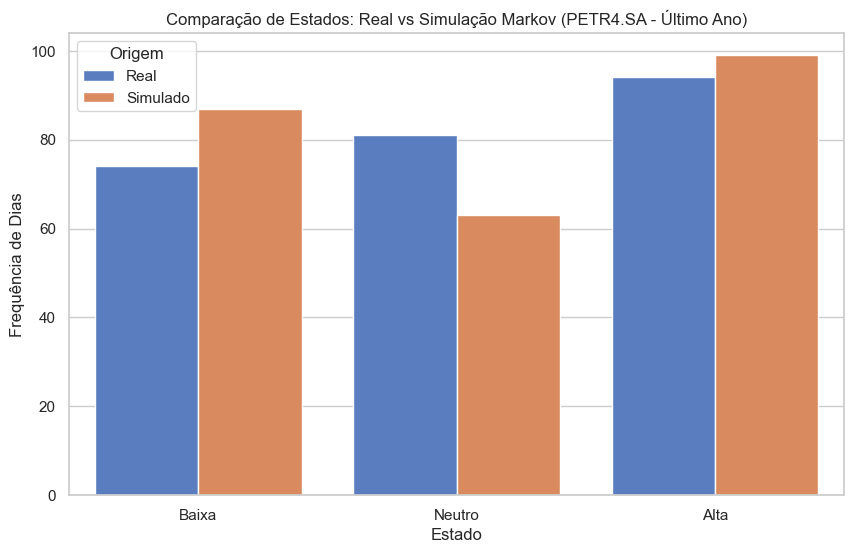

Distribuição Real no Teste:
  Baixa: 29.7%
  Neutro: 32.5%
  Alta: 37.8%

Distribuição Simulada (baseada na matriz de treino):
  Baixa: 34.9%
  Neutro: 25.3%
  Alta: 39.8%


In [6]:
# ==========================================
# 4. SIMULAÇÃO E COMPARAÇÃO NO TESTE
# ==========================================

# Pegamos o último estado do período de treino para iniciar a simulação
estado_inicial_teste = estados_train[-1]
n_dias_teste = len(df_test)

# Rodando a simulação
simulacao_teste = simular_markov(matriz_petr4, estado_inicial_teste, n_dias_teste-1)

# Dados reais do período de teste
estados_reais_teste = df_test['Estado'].values

# Preparando os dados para o gráfico comparativo
df_comparacao = pd.DataFrame({
    'Estado_Num': np.concatenate([estados_reais_teste, simulacao_teste]),
    'Origem': ['Real'] * n_dias_teste + ['Simulado'] * n_dias_teste
})
df_comparacao['Estado'] = df_comparacao['Estado_Num'].map({0: 'Baixa', 1: 'Neutro', 2: 'Alta'})

# --- Gráfico: Comparação de Histogramas ---
plt.figure(figsize=(10, 6))
sns.countplot(data=df_comparacao, x='Estado', hue='Origem', order=estados, palette="muted")
plt.title(f"Comparação de Estados: Real vs Simulação Markov ({ticker} - Último Ano)")
plt.ylabel("Frequência de Dias")
plt.show()

# Imprimindo percentuais finais
dist_real = pd.Series(estados_reais_teste).value_counts(normalize=True).sort_index()
dist_simul = pd.Series(simulacao_teste).value_counts(normalize=True).sort_index()

print("Distribuição Real no Teste:")
for k, v in dist_real.items(): print(f"  {estados[k]}: {v*100:.1f}%")
    
print("\nDistribuição Simulada (baseada na matriz de treino):")
for k, v in dist_simul.items(): print(f"  {estados[k]}: {v*100:.1f}%")

## 5. Análise de Convergência e Distribuição de Transições (PETR4)

Nesta etapa, aprofundamos a análise visual dos dados reais (Treinamento e Teste). Nosso objetivo é observar três aspectos fundamentais do comportamento estocástico do ativo:

1. **Evolução e Convergência:** Pela Lei dos Grandes Números, a proporção acumulada de visitas a cada estado empírico deve convergir para a distribuição estacionária $\pi$. Vamos visualizar se o comportamento de longo prazo no Treinamento se mantém estável no período de Teste.
   $$\lim_{N \to \infty} \frac{1}{N} \sum_{t=1}^{N} I(X_t = i) = \pi_i$$
   *(Onde $I$ é a função indicadora de visita ao estado $i$)*

2. **Histograma de Estados:** Uma comparação direta do volume bruto de dias em que o ativo fechou em Alta, Baixa ou Neutro, contrastando os períodos de Treinamento e Teste.

3. **Histograma das Transições:** Ao invés de uma representação matricial, visualizaremos a frequência de cada par de transição (ex: de "Baixa" para "Alta", de "Alta" para "Neutro"). O espaço amostral de transições é dado por $S \times S$, resultando em 9 combinações possíveis para os nossos 3 estados.

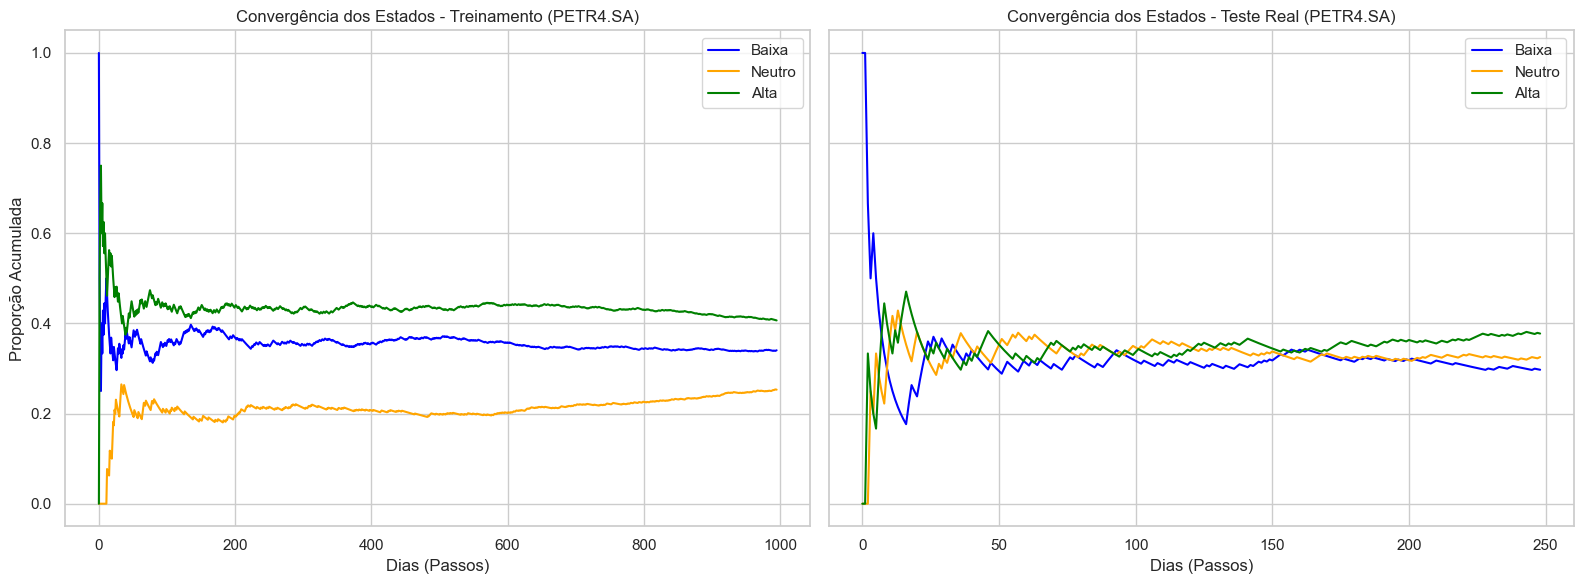

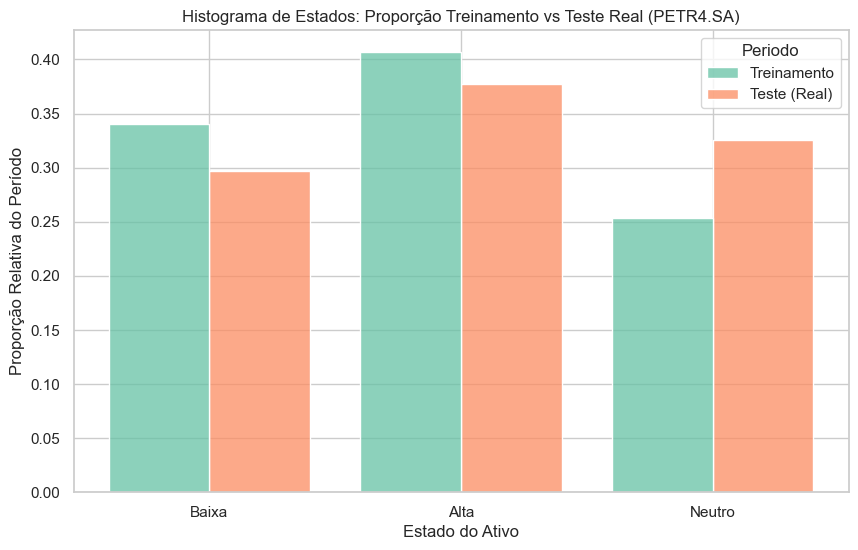

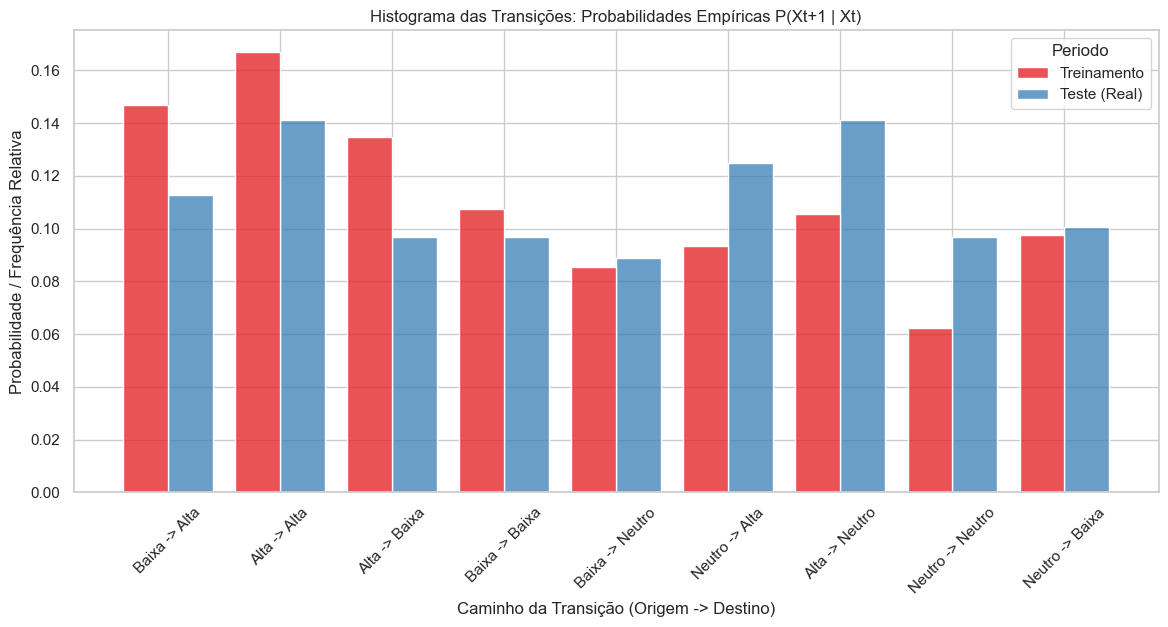

In [7]:
# ==========================================
# 5. VISUALIZAÇÕES DE CONVERGÊNCIA E TRANSIÇÕES
# ==========================================

# Criação de DataFrames auxiliares para os gráficos
df_estados_treino = pd.DataFrame({'Estado_Num': estados_train, 'Periodo': 'Treinamento'})
df_estados_teste_real = pd.DataFrame({'Estado_Num': estados_reais_teste, 'Periodo': 'Teste (Real)'})

df_completo = pd.concat([df_estados_treino, df_estados_teste_real])
df_completo['Estado'] = df_completo['Estado_Num'].map({0: 'Baixa', 1: 'Neutro', 2: 'Alta'})

# ---------------------------------------------------------
# GRÁFICO 1: Evolução da Proporção dos Estados (Convergência)
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Evolução no Treinamento
for estado_num, cor, label in zip([0, 1, 2], ['blue', 'orange', 'green'], ['Baixa', 'Neutro', 'Alta']):
    evolucao_treino = np.cumsum(estados_train == estado_num) / np.arange(1, len(estados_train) + 1)
    axes[0].plot(evolucao_treino, color=cor, label=f'{label}')
axes[0].set_title(f'Convergência dos Estados - Treinamento ({ticker})')
axes[0].set_xlabel('Dias (Passos)')
axes[0].set_ylabel('Proporção Acumulada')
axes[0].legend()

# Evolução no Teste
for estado_num, cor, label in zip([0, 1, 2], ['blue', 'orange', 'green'], ['Baixa', 'Neutro', 'Alta']):
    evolucao_teste = np.cumsum(estados_reais_teste == estado_num) / np.arange(1, len(estados_reais_teste) + 1)
    axes[1].plot(evolucao_teste, color=cor, label=f'{label}')
axes[1].set_title(f'Convergência dos Estados - Teste Real ({ticker})')
axes[1].set_xlabel('Dias (Passos)')
axes[1].legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# GRÁFICO 2: Histograma Comparativo de Estados
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
# Usamos stat="percent" para normalizar os tamanhos diferentes de Treino e Teste
sns.histplot(data=df_completo, x='Estado', hue='Periodo', multiple='dodge', 
             stat='proportion', common_norm=False, shrink=0.8, palette='Set2')
plt.title(f'Histograma de Estados: Proporção Treinamento vs Teste Real ({ticker})')
plt.ylabel('Proporção Relativa do Período')
plt.xlabel('Estado do Ativo')
plt.show()

# ---------------------------------------------------------
# GRÁFICO 3: Histograma das Transições
# ---------------------------------------------------------
# Extraindo os pares de transição (t, t+1) para Treino e Teste
transicoes_treino = [f"{estados[estados_train[i]]} -> {estados[estados_train[i+1]]}" for i in range(len(estados_train)-1)]
transicoes_teste = [f"{estados[estados_reais_teste[i]]} -> {estados[estados_reais_teste[i+1]]}" for i in range(len(estados_reais_teste)-1)]

df_transicoes_treino = pd.DataFrame({'Transicao': transicoes_treino, 'Periodo': 'Treinamento'})
df_transicoes_teste = pd.DataFrame({'Transicao': transicoes_teste, 'Periodo': 'Teste (Real)'})

df_transicoes = pd.concat([df_transicoes_treino, df_transicoes_teste])

# Ordenando as transições de forma lógica
ordem_transicoes = [f"{orig} -> {dest}" for orig in estados for dest in estados]

plt.figure(figsize=(14, 6))
sns.histplot(data=df_transicoes, x='Transicao', hue='Periodo', multiple='dodge', 
             stat='proportion', common_norm=False, shrink=0.8, palette='Set1')
plt.title('Histograma das Transições: Probabilidades Empíricas P(Xt+1 | Xt)')
plt.ylabel('Probabilidade / Frequência Relativa')
plt.xlabel('Caminho da Transição (Origem -> Destino)')
plt.xticks(rotation=45)
plt.show()

## 6. Avaliação de Performance Preditiva do Modelo

Embora as Cadeias de Markov sejam essencialmente modelos probabilísticos, podemos testar sua utilidade direcional como um "oráculo" de classificação. 

**Regra de Previsão:** Para cada dia $t$ no período de teste, o modelo observa o estado real $X_t$. A previsão para o dia $t+1$ ($\hat{X}_{t+1}$) será o estado com a maior probabilidade de transição a partir de $X_t$, de acordo com a matriz aprendida no período de treinamento.
$$\hat{X}_{t+1} = \arg\max_{j} P(X_{t+1}=j \mid X_t=i)$$

Utilizaremos as seguintes métricas clássicas de Machine Learning para avaliar os resultados:
* **Matriz de Confusão:** Para visualizar os acertos e os tipos de erros (ex: previu Alta, mas foi Baixa).
* **Acurácia:** O percentual total de acertos.
* **Relatório de Classificação:** Contendo Precisão (quantos dos previstos estavam corretos), Recall (quantos dos reais foram identificados) e F1-Score para cada estado.

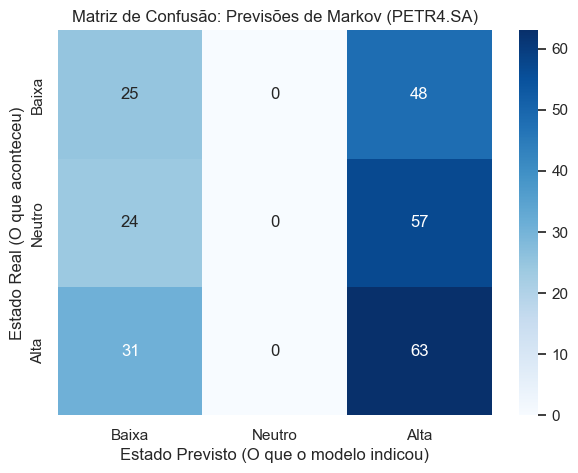

MÉTRICAS DE DESEMPENHO - CADEIA DE MARKOV (PETR4.SA)
Acurácia Global do Modelo: 35.48%

Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

       Baixa       0.31      0.34      0.33        73
      Neutro       0.00      0.00      0.00        81
        Alta       0.38      0.67      0.48        94

    accuracy                           0.35       248
   macro avg       0.23      0.34      0.27       248
weighted avg       0.23      0.35      0.28       248

--------------------------------------------------
Certeza média teórica do modelo (Probabilidade máx. média): 40.89%
Nota: No mercado financeiro (Passeio Aleatório), matrizes de transição costumam ter
probabilidades muito divididas (ex: 33% para cada estado), o que explica acurácias
frequentemente próximas do limiar da aleatoriedade.


In [8]:
# ==========================================
# 6. MÉTRICAS DE AVALIAÇÃO DE PERFORMANCE
# ==========================================
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Gerando as previsões do modelo baseadas na maior probabilidade da matriz de transição
previsoes_teste = []
reais_teste = estados_reais_teste[1:] # O valor real do 'dia seguinte'

for estado_atual in estados_reais_teste[:-1]:
    # A previsão é o índice com a maior probabilidade na linha correspondente ao estado atual
    estado_previsto = np.argmax(matriz_petr4[estado_atual])
    previsoes_teste.append(estado_previsto)

previsoes_teste = np.array(previsoes_teste)

# 2. Calculando a Matriz de Confusão
matriz_confusao = confusion_matrix(reais_teste, previsoes_teste)

# Plotando a Matriz de Confusão
plt.figure(figsize=(7, 5))
sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='Blues', 
            xticklabels=estados, yticklabels=estados)
plt.title(f'Matriz de Confusão: Previsões de Markov ({ticker})')
plt.ylabel('Estado Real (O que aconteceu)')
plt.xlabel('Estado Previsto (O que o modelo indicou)')
plt.show()

# 3. Calculando Acurácia e Relatório de Classificação
acuracia = accuracy_score(reais_teste, previsoes_teste)

print("="*50)
print(f"MÉTRICAS DE DESEMPENHO - CADEIA DE MARKOV ({ticker})")
print("="*50)
print(f"Acurácia Global do Modelo: {acuracia:.2%}\n")

print("Relatório de Classificação Detalhado:")
print(classification_report(reais_teste, previsoes_teste, target_names=estados, zero_division=0))

# 4. Análise Crítica dos Resultados
# Extraindo a maior probabilidade média nas transições para entender o nível de "certeza" do modelo
certeza_media = np.mean(np.max(matriz_petr4, axis=1))
print("-" * 50)
print(f"Certeza média teórica do modelo (Probabilidade máx. média): {certeza_media:.2%}")
print("Nota: No mercado financeiro (Passeio Aleatório), matrizes de transição costumam ter")
print("probabilidades muito divididas (ex: 33% para cada estado), o que explica acurácias")
print("frequentemente próximas do limiar da aleatoriedade.")